In [135]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os

def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
    for folder_name in subfolder_names:
        # Construct the full path for the new subfolder
        subfolder_path = os.path.join(parent_directory, folder_name)
        try:
            # Create the main subfolder
            os.makedirs(subfolder_path)
            print(f"Created subfolder: {subfolder_path}")

            # Create nested subfolders
            for nested_folder_name in nested_subfolder_names:
                nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
                os.makedirs(nested_subfolder_path)
                print(f"Created nested subfolder: {nested_subfolder_path}")
        except OSError as error:
            print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex4"

# # Generate main subfolder names T1, T2, ..., T50
# subfolder_names = [f"T{i}" for i in range(1, 51)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)


def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

def gradient_x1(x):
    return 1.0

def gradient_x2(x):
    return 1.0

def gradient(x):
    return np.array([gradient_x1(x),gradient_x2(x)])


n= 2
alpha= np.random.uniform(0, sqrt(2)-1)

def F(x,lamd= 0.0):
  return np.array([(2*x[0]-x[1]-1)+lamd*gradient_x1(x),(2*x[1]-0.5*x[0]-2)+lamd*gradient_x2(x)])

n= 2




def proj_X_opt(x):
    """
    Project point x = (x1, x2) onto
    X = { (u,v) | u >= 0, v >= 0, u+v <= 1 }
    """
    x = np.asarray(x)

    # Objective: minimize squared distance
    def objective(u):
        return 0.5 * np.sum((u - x)**2)

    # Constraints
    constraints = [
        {"type": "ineq", "fun": lambda u: u[0]},          # u >= 0
        {"type": "ineq", "fun": lambda u: u[1]},          # v >= 0
        {"type": "ineq", "fun": lambda u: 1 - u[0] - u[1]} # u+v <= 1
    ]

    # Initial guess
    z0 = np.maximum(x, 0)  # clip negative values to start inside nonnegative orthant
    bounds = [(0, 1), (0, 1)]

    result = minimize(objective, z0, constraints=constraints, bounds= bounds)

    return result.x


def const(x):
    return 1-(x[0]+x[1])



def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints={'type': 'ineq', 'fun': constraint_function},bounds= [(0,1),(0,1)])
    return result.x

num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()


    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x - lambda_value * grad_obj,constraint_function)
    return x

# def vi_solver(lamd):
#     x0= np.random.uniform(0, 1, size=n)
#     y0= x0.copy()

#     T= 1000
#     x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
#     x[0]= x0
#     y[0]= y0
#     lambda_value_0= np.random.uniform(0, alpha)

#     x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
#     y[1]= 2*x[1]-x[0]
#     for i in range(1,T):

#         if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
#             lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
#         else:
#             lambda_value= 0 #1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
#       # break

#         x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
#         y[i+1]= 2*x[i+1]-x[i]
#     if np.abs(const(x[T])*lambda_value)< 1e-8:
#         return x[T]
#     elif np.abs(const(x[T])) < 1e-8:
#         return x[T]
#     else:
#         return None

def vi_solver(lamd):
    n= 2
    x0= np.random.uniform(0, 1, size=n)
    y0= x0.copy()

    T= 1000
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)
#     print(x0)
    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
            if np.abs(const(x[i+1]) * lamd) <= 1e-4:
                return x[i+1]

def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size

    Returns:
    - time_points: List of discretized time points
    """
    start = 0#T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#number_points_list= [10, 20]
#n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
#number_points_list= [100, 200]
T_list= [T for T in range(1,2)]
# n_runs= [10]

def run_for_lam(lmb):
    results = Parallel(n_jobs=-1)(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points

def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)
def run_(lambd):
    results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


# def run_for_different_runs(T,n_r= 10):
#     lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
#     result= run_for_lam_run(lambd,n_r)
   
#     for idx_run in range(n_r):
#         results= result[idx_run]
# # #         results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
#         for n_points in range(len(results)):
#             np.savetxt('./solns_runs/Ex4/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')




In [136]:
T= 1
lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)


In [137]:
# len(lambd)
vi_solver(0.0)

array([0.35405066, 0.64594934])

In [138]:
tt= run_for_lam(lambd[0])
# tt= run_n(lambd[0])

In [139]:
tt

[[0.49607856516899285, 0.5039214348310072],
 [0.3201873860668337, 0.6798126139331664],
 [0.4020378181333934, 0.5979621818666064],
 [0.23344920964213656, 0.7665507903578636],
 [0.4088678891106129, 0.5911321108893871],
 [0.41420250560186933, 0.5857974943981307],
 [0.3719349169465106, 0.6280650830534894],
 [0.4150628609849224, 0.5849371390150777],
 [0.4354403385202552, 0.5645596614797448],
 [0.4007123388149152, 0.5992876611850848],
 [0.3644772990444785, 0.6355227009555215],
 [0.42866575225601466, 0.5713342477439853],
 [0.5352995753940287, 0.46470042460597133],
 [0.4851807002785346, 0.5148192997214653],
 [0.25903087878028463, 0.7409691212197154],
 [0.4275291961577058, 0.5724708038422943],
 [0.3448333954767842, 0.6551666045232158],
 [0.41330254190314397, 0.5866974580968561],
 [0.32266836098670826, 0.6773316390132915],
 [0.3720359337849396, 0.6279640662150603],
 [0.3884679297368701, 0.6115320702631298],
 [0.40775984984300007, 0.5922401501569998],
 [0.43252453322114937, 0.5674754667788506],
 

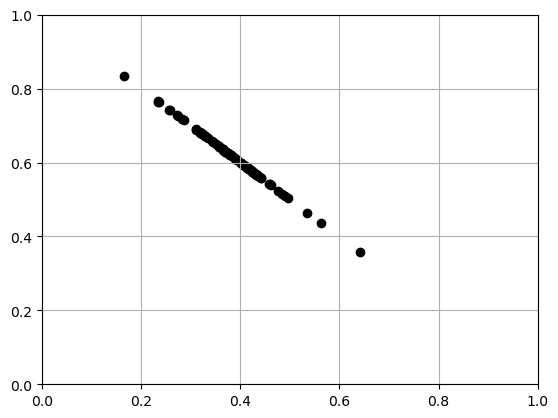

In [140]:
plt.scatter(np.array(tt)[:,0], np.array(tt)[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.show()

In [112]:
# results = Parallel(n_jobs=2)(delayed(run_for_lam)(lam) for lam in lambd)

In [89]:
# vi_solver(0.0)

In [90]:
# data= []

In [91]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [92]:
# data

In [93]:
# all_data= dict.fromkeys(range(len(data)), 0)

In [94]:
# for i in range(len(data)):
#     all_data[i]= data[i]

In [95]:
# import json
# with open("Ex2PVI.json", "w") as f:
#     json.dump(all_data, f)

In [96]:
# Filter solutions

In [97]:
# T= 5
# n_runs= 3

In [98]:
# All T

In [141]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [142]:
T_list= [1, 2, 3, 4, 5, 6, 7, 8]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

In [143]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

Running for T=  1
15
Running for T=  2
15
Running for T=  3
15
Running for T=  4
15
Running for T=  5
15


In [103]:
# import json
# with open("Ex2PVIT.json", "w") as f:
#     json.dump(T_data, f)

In [104]:
T_data

{1: [array([[0.31678822, 0.68321178],
         [0.33376247, 0.66623753],
         [0.32493526, 0.67506474],
         ...,
         [0.36273072, 0.63726928],
         [0.36303431, 0.63696569],
         [0.36333664, 0.63666336]]),
  array([[0.32970568, 0.67029432],
         [0.33107369, 0.66892631],
         [0.33517055, 0.66482945],
         ...,
         [0.36320156, 0.63679844],
         [0.36335198, 0.63664802],
         [0.36350225, 0.63649775]]),
  array([[0.33506277, 0.66493723],
         [0.31646104, 0.68353896],
         [0.33522913, 0.66477087],
         ...,
         [0.36335731, 0.63664269],
         [0.36345662, 0.63654338],
         [0.36355659, 0.63644341]]),
  array([[0.32978273, 0.67021727],
         [0.31904783, 0.68095217],
         [0.31189973, 0.68810027],
         ...,
         [0.36343408, 0.63656592],
         [0.36350924, 0.63649076],
         [0.36358374, 0.63641626]]),
  array([[0.33815483, 0.66184517],
         [0.32937084, 0.67062916],
         [0.32765422, 0

In [144]:
# import json
# with open("Ex2PVIT.json", "w") as f:
#     json.dump(T_data, f)

import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex2PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [146]:
T_data[3]

[array([[0.32016197, 0.67983803],
        [0.14394286, 0.85605714],
        [0.3929078 , 0.6070922 ],
        [0.37879177, 0.62120823],
        [0.36711974, 0.63288026],
        [0.48318536, 0.51681464],
        [0.38991056, 0.61008944],
        [0.37181034, 0.62818966],
        [0.31430783, 0.68569217],
        [0.40098663, 0.59901337],
        [0.31050913, 0.68949087],
        [0.3545623 , 0.6454377 ],
        [0.571512  , 0.428488  ],
        [0.47167876, 0.52831743],
        [0.30818623, 0.69181377],
        [0.40722148, 0.59277852],
        [0.26361348, 0.73638652],
        [0.21368604, 0.78631396],
        [0.38751333, 0.61248667],
        [0.34274658, 0.65725342],
        [0.43347008, 0.56652992],
        [0.40493819, 0.59506181],
        [0.31465003, 0.68534997],
        [0.37347361, 0.62652639],
        [0.34124358, 0.65875642],
        [0.38223222, 0.61776778],
        [0.36384823, 0.63615177],
        [0.40479583, 0.59520417],
        [0.4099445 , 0.5900555 ],
        [0.314

In [38]:
# with open("Ex2PVIT.json", "r") as f:
#     T_data = json.load(f)

# with open("Ex2PVIT678.json", "r") as f:
#     T_data678 = json.load(f)
# # T_data[str(5)]
# T_data["6"] = T_data678["6"]
# T_data["7"] = T_data678["7"]
# T_data["8"] = T_data678["8"]

# def convert(obj):
#     if isinstance(obj, np.ndarray):
#         return obj.tolist()
#     if isinstance(obj, np.integer):
#         return int(obj)
#     if isinstance(obj, np.floating):
#         return float(obj)
#     raise TypeError(f"Type {type(obj)} not serializable")
    
# # Save again
# with open("Ex2PVIT.json", "w") as f:
#     json.dump(T_data, f, default=convert)

# Track $T_{max}$

In [39]:
import json
import numpy as np

import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])


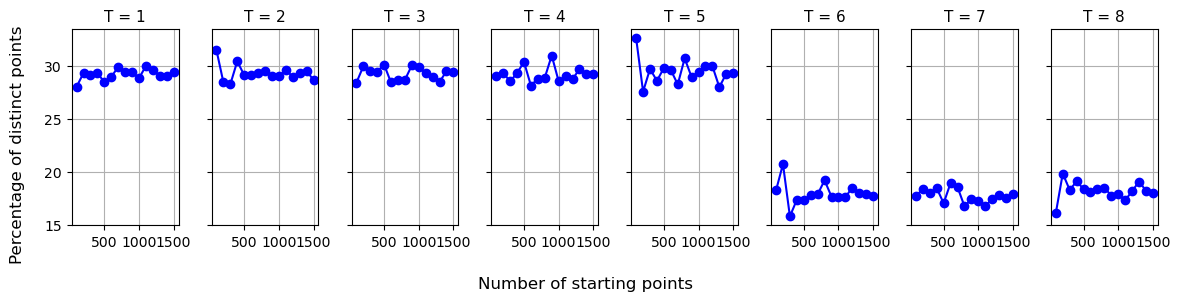

In [41]:
with open('./Ex2PVIT.json') as f:
    dataT= json.load(f)
    
    
T_list= [1, 2, 3, 4, 5, 6, 7, 8] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                if np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-6:
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all


dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res


import numpy as np
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points


res_T= {
    1: None, 2: None, 3: None, 4: None, 5: None, 6: None, 7: None, 8:None
}
Tmax= 8

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):




        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o', c= 'blue')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
#plt.savefig("Ex2Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
np.mean(res_T[1])

29.175075925296916

In [36]:
means = {k: sum(v)/len(v) for k,v in res_T.items()}
means

{1: 29.175075925296916,
 2: 29.305918032587048,
 3: 29.23193602319047,
 4: 29.175985162317772,
 5: 29.43139101614249}

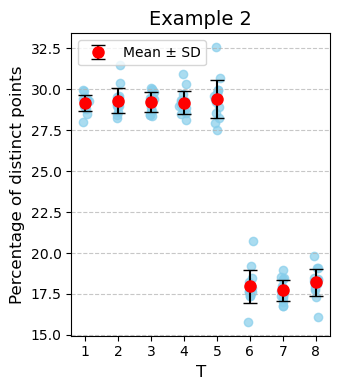

In [42]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 2', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex2Tmax.png", dpi=300, bbox_inches="tight")
plt.show()